# loss 역전 실험 — `sharp only` < `both`인 이유를 분해해서 본다

노트북 5절의 네 설정을 실제로 학습시키고, **loss 순위와 표현 품질 순위가 어긋나는 것**을
세 장의 그림으로 확인한다.

1. 설정별 학습곡선 — 같은 x축(step) 위에 loss와 `code_acc`를 이중 y축으로
2. 최종 loss vs 품질 산점도 — 상관이 0 또는 음수
3. loss를 $h(q)$와 $KL$로 스택 분해 — `sharp only`의 낮은 loss는 $h(q)\approx 0$ 때문
4. best-loss 체크포인트 ≠ best-품질 체크포인트

품질 지표는 두 개를 같이 쓴다.

- `code_acc` : 코드별 다수결로 클러스터를 맞히는 정확도 (노트북 5절 지표)
- $I = h(\bar q) - \overline{h(q)}$ : "코드가 입력에 대해 갖는 정보량". 두 붕괴 모두에서 0으로 가고,
  건강할 때만 크다. `code_acc`는 코드가 잘게 쪼개지면 다수결이 유리해져 부풀 수 있어서 $I$를 함께 본다.

In [1]:
import math
import copy
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import spearmanr, pearsonr

torch.manual_seed(0)

try:
    OUT_PNG = os.path.join(os.path.dirname(os.path.abspath(__file__)), "expy.png")
except NameError:
    OUT_PNG = "expy.png"


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:
            fig.show()
    except ImportError:
        pass


print("torch", torch.__version__)

torch 2.4.0+cu121


## 노트북 5절 재현 — `MiniDINOLoss` + 토이 데이터

In [2]:
def entropy(p):
    return -(p * p.clamp_min(1e-12).log()).sum(-1)


class MiniDINOLoss(nn.Module):
    def __init__(self, out_dim, ncrops, teacher_temp, student_temp=0.1,
                 center_momentum=0.9, use_center=True):
        super().__init__()
        self.student_temp = student_temp
        self.teacher_temp = teacher_temp
        self.center_momentum = center_momentum
        self.ncrops = ncrops
        self.use_center = use_center
        self.register_buffer("center", torch.zeros(1, out_dim))

    def forward(self, student_output, teacher_output):
        student_out = (student_output / self.student_temp).chunk(self.ncrops)
        center = self.center if self.use_center else 0.0
        teacher_out = F.softmax((teacher_output - center) / self.teacher_temp, dim=-1)
        teacher_out = teacher_out.detach().chunk(2)

        total_loss, n_terms = 0.0, 0
        for iq, q in enumerate(teacher_out):
            for v in range(len(student_out)):
                if v == iq:
                    continue
                loss = torch.sum(-q * F.log_softmax(student_out[v], dim=-1), dim=-1)
                total_loss += loss.mean()
                n_terms += 1
        total_loss /= n_terms
        self.update_center(teacher_output)
        return total_loss

    @torch.no_grad()
    def update_center(self, teacher_output):
        batch_center = teacher_output.mean(dim=0, keepdim=True)
        self.center = self.center * self.center_momentum + batch_center * (1 - self.center_momentum)


def make_data(n_per_cluster=128, n_clusters=6, radius=3.0, spread=0.3, seed=0):
    g = torch.Generator().manual_seed(seed)
    angles = torch.arange(n_clusters) * (2 * math.pi / n_clusters)
    centers = torch.stack([radius * angles.cos(), radius * angles.sin()], -1)
    X = (centers[:, None, :] + spread * torch.randn(n_clusters, n_per_cluster, 2, generator=g)).reshape(-1, 2)
    y = torch.arange(n_clusters).repeat_interleave(n_per_cluster)
    return X, y


X, y = make_data()


def augment(x, sigma=0.7, generator=None):
    noise = torch.randn(x.shape, generator=generator) if generator is not None else torch.randn_like(x)
    return x + sigma * noise


def mlp(in_dim=2, out_dim=32, hidden=128):
    return nn.Sequential(
        nn.Linear(in_dim, hidden), nn.GELU(),
        nn.Linear(hidden, hidden), nn.GELU(),
        nn.Linear(hidden, out_dim),
    )


@torch.no_grad()
def code_metrics(q, labels):
    codes = q.argmax(-1)
    counts = codes.bincount(minlength=q.shape[-1])
    top_share = counts.max().item() / len(codes)
    correct = sum(labels[codes == c].bincount().max().item() for c in codes.unique())
    return top_share, correct / len(labels)


# 모든 설정·모든 스텝에서 동일하게 쓰는 고정 평가 배치 (분해가 서로 비교 가능하도록)
_g = torch.Generator().manual_seed(1234)
VIEWS_EVAL = torch.cat([augment(X, generator=_g), augment(X, generator=_g)])
print("eval views:", tuple(VIEWS_EVAL.shape))

eval views: (1536, 2)


## loss 분해 — $H(q,p) = h(q) + D_{KL}(q\|p)$

고정 평가 배치 위에서 DINO와 똑같은 crop 짝짓기로 $H$, $h(q)$, $KL$을 **따로** 잰다.
정의상 항상 $H = h(q) + KL$이므로, 설정 간 loss 차이가 어느 항에서 오는지 바로 읽을 수 있다.

In [3]:
@torch.no_grad()
def decompose(student, teacher, loss_fn, use_center, views=VIEWS_EVAL):
    center = loss_fn.center if use_center else 0.0
    q_all = F.softmax((teacher(views) - center) / loss_fn.teacher_temp, -1)
    s_all = student(views) / loss_fn.student_temp
    qs, ss = q_all.chunk(2), s_all.chunk(2)
    logp = [F.log_softmax(x, -1) for x in ss]

    H = hq = KL = 0.0
    n = 0
    for iq in range(2):
        for v in range(2):
            if v == iq:
                continue
            H += (-(qs[iq] * logp[v]).sum(-1)).mean().item()
            hq += entropy(qs[iq]).mean().item()
            KL += (qs[iq] * (qs[iq].clamp_min(1e-12).log() - logp[v])).sum(-1).mean().item()
            n += 1
    return H / n, hq / n, KL / n


@torch.no_grad()
def teacher_dist(teacher, loss_fn, use_center, teacher_temp):
    logits = teacher(X)
    center = loss_fn.center if use_center else 0.0
    return F.softmax((logits - center) / teacher_temp, -1)


def train(use_center, teacher_temp, steps=1500, out_dim=32, m=0.99, lr=1e-3,
          batch=256, log_every=25, seed=0):
    torch.manual_seed(seed)
    student = mlp(out_dim=out_dim)
    teacher = copy.deepcopy(student)
    for p in teacher.parameters():
        p.requires_grad_(False)
    opt = torch.optim.Adam(student.parameters(), lr=lr)
    loss_fn = MiniDINOLoss(out_dim, ncrops=2, teacher_temp=teacher_temp, use_center=use_center)

    keys = ["step", "loss", "H", "h_q", "KL", "h_each", "h_mean", "I", "top_share", "code_acc"]
    hist = {k: [] for k in keys}
    for step in range(steps):
        idx = torch.randint(0, len(X), (batch,))
        views = torch.cat([augment(X[idx]), augment(X[idx])])
        s_out = student(views)
        with torch.no_grad():
            t_out = teacher(views)
        loss = loss_fn(s_out, t_out)

        opt.zero_grad()
        loss.backward()
        opt.step()

        with torch.no_grad():
            for ps, pt in zip(student.parameters(), teacher.parameters()):
                pt.mul_(m).add_((1 - m) * ps)

        if step % log_every == 0 or step == steps - 1:
            q = teacher_dist(teacher, loss_fn, use_center, teacher_temp)
            top, acc = code_metrics(q, y)
            H, hq, KL = decompose(student, teacher, loss_fn, use_center)
            h_each = entropy(q).mean().item()
            h_mean = entropy(q.mean(0)).item()
            hist["step"].append(step)
            hist["loss"].append(loss.item())
            hist["H"].append(H)
            hist["h_q"].append(hq)
            hist["KL"].append(KL)
            hist["h_each"].append(h_each)
            hist["h_mean"].append(h_mean)
            hist["I"].append(h_mean - h_each)          # 코드가 담은 정보량 (두 붕괴 모두 → 0)
            hist["top_share"].append(top)
            hist["code_acc"].append(acc)
    return hist, teacher, loss_fn


CONFIGS = {
    "none": dict(use_center=False, teacher_temp=0.1),
    "center only": dict(use_center=True, teacher_temp=0.1),
    "sharp only": dict(use_center=False, teacher_temp=0.04),
    "both = DINO": dict(use_center=True, teacher_temp=0.04),
}

results = {}
for name, cfg in CONFIGS.items():
    hist, teacher, loss_fn = train(**cfg)
    results[name] = hist
names = list(CONFIGS)
print("done:", names)

done: ['none', 'center only', 'sharp only', 'both = DINO']


## 표 1 — loss 순위와 품질 순위가 어긋난다

In [4]:
final = {n: {k: results[n][k][-1] for k in results[n] if k != "step"} for n in names}

print(f"{'config':14s} {'loss':>6s} {'H(eval)':>8s} {'code_acc':>9s} {'I':>6s} {'h_each':>7s} {'h_mean':>7s} {'top_share':>10s}")
for n in names:
    f = final[n]
    print(f"{n:14s} {f['loss']:6.2f} {f['H']:8.2f} {f['code_acc']:9.2f} {f['I']:6.2f} "
          f"{f['h_each']:7.2f} {f['h_mean']:7.2f} {f['top_share']:10.2f}")
print(f"\nlog K = {math.log(32):.2f},  log 6 = {math.log(6):.2f},  chance code_acc = {1/6:.2f}")

config           loss  H(eval)  code_acc      I  h_each  h_mean  top_share
none             2.91     2.92      0.33   0.11    2.90    3.01       0.83
center only      3.37     3.37      0.83   0.11    3.36    3.46       0.33
sharp only       0.22     0.26      0.67   1.24    0.00    1.24       0.50
both = DINO      0.82     0.92      1.00   1.79    0.59    2.38       0.17

log K = 3.47,  log 6 = 1.79,  chance code_acc = 0.17


In [5]:
loss_v = [final[n]["loss"] for n in names]
acc_v = [final[n]["code_acc"] for n in names]
I_v = [final[n]["I"] for n in names]

rho_acc, p_acc = spearmanr(loss_v, acc_v)
rho_I, p_I = spearmanr(loss_v, I_v)
r_acc, _ = pearsonr(loss_v, acc_v)
r_I, _ = pearsonr(loss_v, I_v)

print(f"spearman(loss, code_acc) = {rho_acc:+.3f}  (p={p_acc:.3f})   pearson = {r_acc:+.3f}")
print(f"spearman(loss, I)        = {rho_I:+.3f}  (p={p_I:.3f})   pearson = {r_I:+.3f}")
print("loss 오름차순  :", [names[i] for i in sorted(range(4), key=lambda i: loss_v[i])])
print("code_acc 내림차순:", [names[i] for i in sorted(range(4), key=lambda i: -acc_v[i])])
print("I 내림차순      :", [names[i] for i in sorted(range(4), key=lambda i: -I_v[i])])

spearman(loss, code_acc) = +0.000  (p=1.000)   pearson = -0.336
spearman(loss, I)        = -0.600  (p=0.400)   pearson = -0.903
loss 오름차순  : ['sharp only', 'both = DINO', 'none', 'center only']
code_acc 내림차순: ['both = DINO', 'center only', 'sharp only', 'none']
I 내림차순      : ['both = DINO', 'sharp only', 'center only', 'none']


loss로 1등인 `sharp only`가 $I$로는 2등, `code_acc`로는 3등이다.
상관이 **0(`code_acc`) 또는 강한 음수($I$: 스피어만 $-0.60$, 피어슨 $-0.90$)** — "loss가 낮을수록 좋다"가
여기서는 성립하지 않는다. loss를 기준으로 이 4개 중 하나를 고르면 붕괴 중인 설정을 집게 된다.

## 표 2 — loss 차이는 거의 전부 $h(q)$에서 온다

In [6]:
print(f"{'config':14s} {'H':>6s} {'h(q)':>6s} {'KL':>6s}   {'h(q) 비중':>9s}")
for n in names:
    f = final[n]
    print(f"{n:14s} {f['H']:6.2f} {f['h_q']:6.2f} {f['KL']:6.2f}   {f['h_q']/f['H']*100:8.1f}%")

dH = final["both = DINO"]["H"] - final["sharp only"]["H"]
dh = final["both = DINO"]["h_q"] - final["sharp only"]["h_q"]
dK = final["both = DINO"]["KL"] - final["sharp only"]["KL"]
print(f"\nboth - sharp only :  ΔH = {dH:+.3f}  =  Δh(q) {dh:+.3f}  +  ΔKL {dK:+.3f}")
print(f"loss 격차 중 h(q)가 설명하는 비율 = {dh/dH*100:.1f}%")

config              H   h(q)     KL     h(q) 비중
none             2.92   2.91   0.01       99.7%
center only      3.37   3.36   0.01       99.7%
sharp only       0.26   0.05   0.21       18.6%
both = DINO      0.92   0.64   0.29       68.9%

both - sharp only :  ΔH = +0.663  =  Δh(q) +0.588  +  ΔKL +0.075
loss 격차 중 h(q)가 설명하는 비율 = 88.6%


**핵심 수치.** `both`가 `sharp only`보다 loss가 0.66 높은데, 그중 0.59(89%)가 $h(q)$ 차이다.
나머지 0.075만이 $KL$ 차이 — 즉 "student가 teacher를 못 따라가서" 생긴 격차가 아니다.

`sharp only`는 $h(q)=0.05$, teacher가 거의 원-핫이라 loss가 사실상 $KL$뿐이고,
그 하드 타깃은 맞히기 쉬워서 loss가 낮다.
`both`의 높은 loss는 **teacher가 불확실성을 정직하게 표현한 대가**로 지불한 $h(q)=0.64$다.

## 표 3 — best-loss 체크포인트 vs best-품질 체크포인트

초기 몇 스텝은 랜덤 초기화의 코드가 잘게 흩어져 `code_acc`가 부풀기 때문에 warmup 100 스텝은 제외한다.

In [7]:
WARMUP = 100
ckpt = {}
for n in names:
    r = results[n]
    idxs = [i for i, s in enumerate(r["step"]) if s >= WARMUP]
    i_loss = min(idxs, key=lambda i: r["H"][i])
    i_acc = max(idxs, key=lambda i: r["code_acc"][i])
    ckpt[n] = dict(step_loss=r["step"][i_loss], acc_at_best_loss=r["code_acc"][i_loss],
                   I_at_best_loss=r["I"][i_loss], best_loss=r["H"][i_loss],
                   step_acc=r["step"][i_acc], best_acc=r["code_acc"][i_acc],
                   loss_at_best_acc=r["H"][i_acc])

print(f"{'config':14s} {'best-loss step':>15s} {'loss':>6s} {'acc there':>10s} | "
      f"{'best-acc step':>14s} {'best acc':>9s} {'loss there':>11s}")
for n in names:
    c = ckpt[n]
    print(f"{n:14s} {c['step_loss']:15d} {c['best_loss']:6.2f} {c['acc_at_best_loss']:10.2f} | "
          f"{c['step_acc']:14d} {c['best_acc']:9.2f} {c['loss_at_best_acc']:11.2f}")

pool = [(n, i) for n in names for i in range(len(results[n]["step"])) if results[n]["step"][i] >= WARMUP]
g_loss = min(pool, key=lambda t: results[t[0]]["H"][t[1]])
g_acc = max(pool, key=lambda t: (results[t[0]]["code_acc"][t[1]], results[t[0]]["I"][t[1]]))
for tag, (n, i) in [("loss 최소", g_loss), ("code_acc 최대", g_acc)]:
    r = results[n]
    print(f"\n{len(pool)}개 체크포인트 중 {tag:12s}: {n:12s} @ step {r['step'][i]:4d}  "
          f"loss={r['H'][i]:.3f}  code_acc={r['code_acc'][i]:.2f}  I={r['I'][i]:.2f}")

config          best-loss step   loss  acc there |  best-acc step  best acc  loss there
none                       100   2.67       0.66 |            250      0.67        2.72
center only                100   3.02       0.83 |            100      0.83        3.02
sharp only                1450   0.26       0.67 |            150      0.67        0.52
both = DINO                600   0.78       1.00 |            150      1.00        1.07

228개 체크포인트 중 loss 최소     : sharp only   @ step 1450  loss=0.257  code_acc=0.67  I=1.24

228개 체크포인트 중 code_acc 최대 : both = DINO  @ step  825  loss=0.873  code_acc=1.00  I=1.79


228개 체크포인트를 **validation loss로 자동 선택**하면 `sharp only` step 1450 (`code_acc` 0.67, $I$ 1.24)을 고른다.
실제 최선은 `both` (`code_acc` 1.00, $I$ 1.79)인데, 그 체크포인트의 loss는 0.87로 3배 이상 높다.
설정 안에서도 `sharp only`는 best-loss(step 1450)와 best-acc(step 150)가 정반대 끝에 있다.

## 그림 — 세 장

saved: /home/sungwoo/projects/swcho/dino/fm/entropy/.fm/hints/d0f02c72-5ad3-4e63-b9e4-a67a61a10049/expy.png


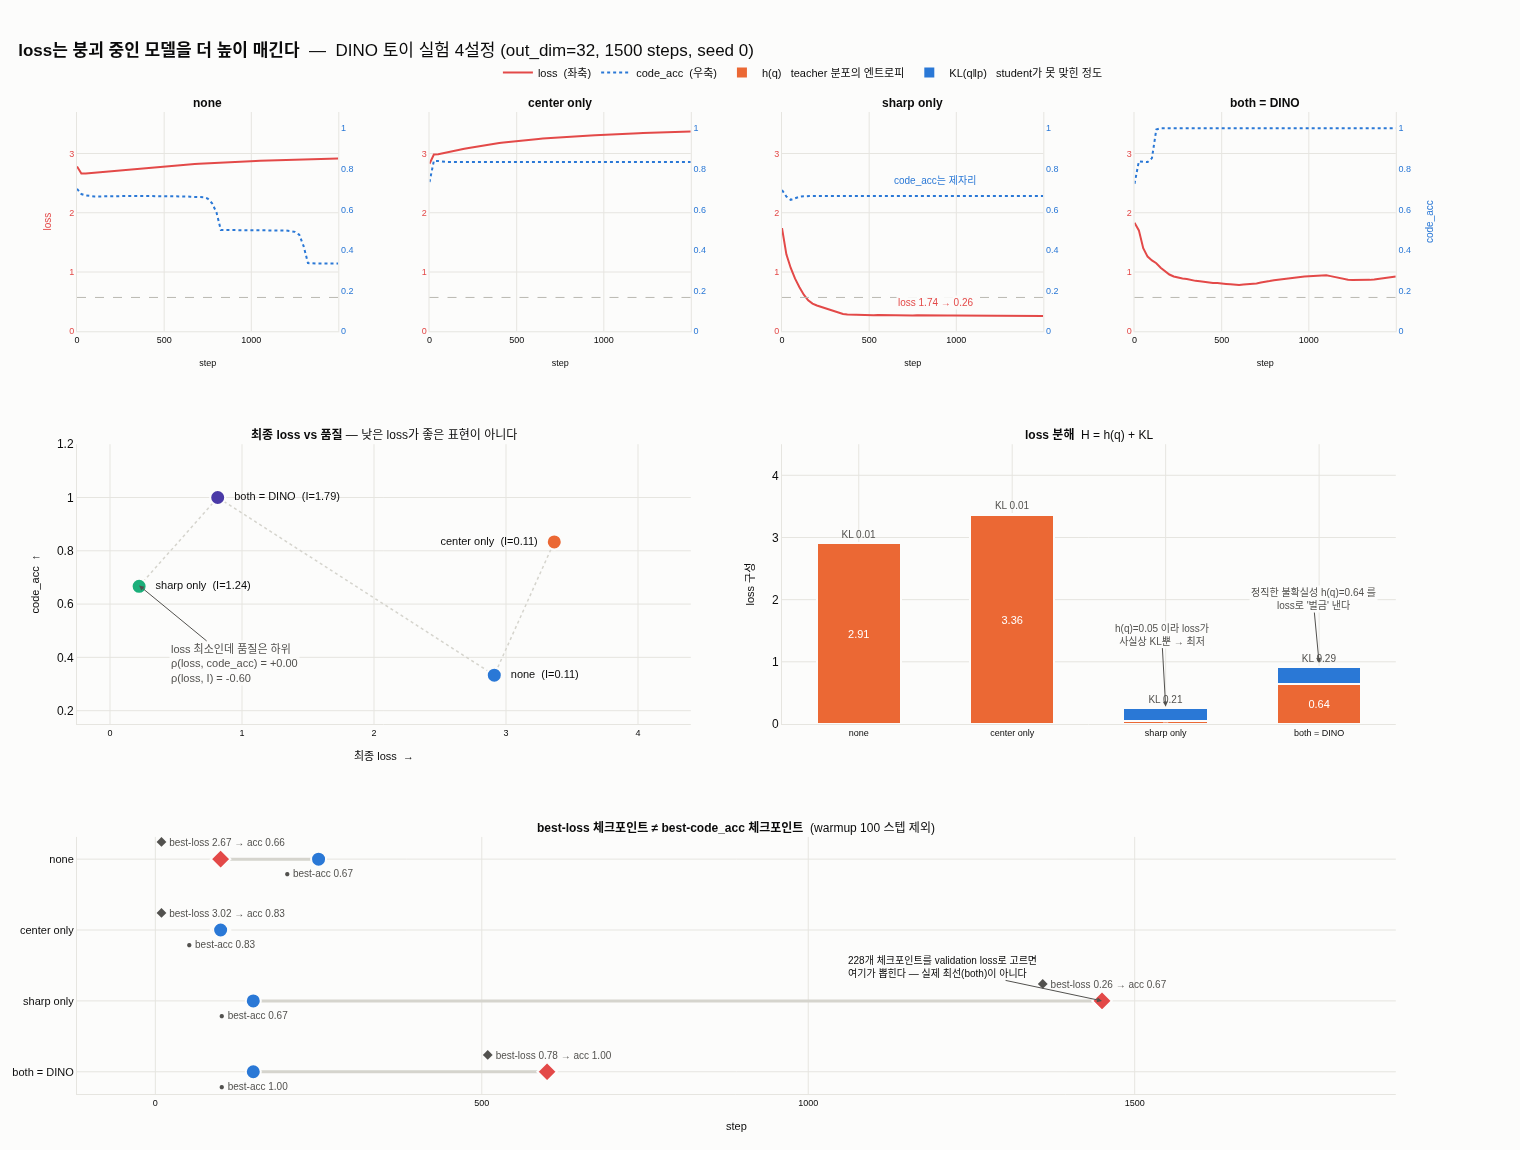

In [8]:
C = {"none": "#2a78d6", "center only": "#eb6834", "sharp only": "#1baf7a", "both = DINO": "#4a3aa7"}
C_LOSS, C_ACC = "#e34948", "#2a78d6"
C_HQ, C_KL = "#eb6834", "#2a78d6"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e0"

fig = make_subplots(
    rows=3, cols=4,
    specs=[[{"secondary_y": True}] * 4,
           [{"colspan": 2}, None, {"colspan": 2}, None],
           [{"colspan": 4}, None, None, None]],
    row_heights=[0.29, 0.37, 0.34],
    vertical_spacing=0.115, horizontal_spacing=0.065,
    subplot_titles=[f"<b>{n}</b>" for n in names]
                   + ["<b>최종 loss vs 품질</b> — 낮은 loss가 좋은 표현이 아니다",
                      "<b>loss 분해</b>  H = h(q) + KL"]
                   + ["<b>best-loss 체크포인트 ≠ best-code_acc 체크포인트</b>  (warmup 100 스텝 제외)"],
)

# (1) 설정별 학습곡선: loss(좌축) / code_acc(우축)
for j, n in enumerate(names, start=1):
    r = results[n]
    fig.add_trace(go.Scatter(x=r["step"], y=r["H"], mode="lines", name="loss  (좌축)",
                             line=dict(color=C_LOSS, width=2), legendgroup="loss",
                             showlegend=(j == 1), hovertemplate="step %{x}<br>loss %{y:.2f}<extra></extra>"),
                  row=1, col=j, secondary_y=False)
    fig.add_trace(go.Scatter(x=r["step"], y=r["code_acc"], mode="lines", name="code_acc  (우축)",
                             line=dict(color=C_ACC, width=2, dash="dot"), legendgroup="acc",
                             showlegend=(j == 1), hovertemplate="step %{x}<br>code_acc %{y:.2f}<extra></extra>"),
                  row=1, col=j, secondary_y=True)
    fig.add_hline(y=1 / 6, line=dict(color="#b9b8b1", width=1, dash="dash"),
                  row=1, col=j, secondary_y=True)
    fig.update_yaxes(range=[0, 3.7], row=1, col=j, secondary_y=False,
                     title_text="loss" if j == 1 else None,
                     title_font=dict(color=C_LOSS, size=10), tickfont=dict(color=C_LOSS, size=9))
    fig.update_yaxes(range=[0, 1.08], row=1, col=j, secondary_y=True,
                     title_text="code_acc" if j == 4 else None,
                     title_font=dict(color=C_ACC, size=10), tickfont=dict(color=C_ACC, size=9),
                     showgrid=False)
    fig.update_xaxes(title_text="step", row=1, col=j, title_font=dict(size=9))

fig.add_annotation(row=1, col=3, secondary_y=False, x=880, y=0.26, text="loss 1.74 → 0.26",
                   showarrow=False, font=dict(size=10, color=C_LOSS), yshift=13,
                   bgcolor="rgba(252,252,251,0.9)")
fig.add_annotation(row=1, col=3, secondary_y=True, x=880, y=0.67, text="code_acc는 제자리",
                   showarrow=False, font=dict(size=10, color=C_ACC), yshift=15,
                   bgcolor="rgba(252,252,251,0.9)")

# (2) 최종 loss vs code_acc 산점도
order = sorted(range(4), key=lambda i: loss_v[i])
fig.add_trace(go.Scatter(x=[loss_v[i] for i in order], y=[acc_v[i] for i in order], mode="lines",
                         line=dict(color="#d5d4cd", width=1.5, dash="dot"),
                         showlegend=False, hoverinfo="skip"), row=2, col=1)
for n in names:
    pos = "middle right" if n != "center only" else "middle left"
    fig.add_trace(go.Scatter(x=[final[n]["loss"]], y=[final[n]["code_acc"]], mode="markers+text",
                             marker=dict(color=C[n], size=15, line=dict(color="#fcfcfb", width=2)),
                             text=[f"  {n}  (I={final[n]['I']:.2f})  "], textposition=pos,
                             textfont=dict(size=11, color=INK), showlegend=False,
                             hovertemplate=f"{n}<br>loss %{{x:.2f}}<br>code_acc %{{y:.2f}}<extra></extra>"),
                  row=2, col=1)
fig.add_annotation(x=0.22, y=0.67, ax=95, ay=78, row=2, col=1,
                   text=f"loss 최소인데 품질은 하위<br>ρ(loss, code_acc) = {rho_acc:+.2f}"
                        f"<br>ρ(loss, I) = {rho_I:+.2f}",
                   showarrow=True, arrowhead=2, arrowcolor=INK2, font=dict(size=11, color=INK2),
                   align="left", bgcolor="rgba(252,252,251,0.88)")
fig.update_xaxes(title_text="최종 loss  →", row=2, col=1, range=[-0.25, 4.4], title_font=dict(size=11))
fig.update_yaxes(title_text="code_acc  ↑", row=2, col=1, range=[0.15, 1.2], title_font=dict(size=11))

# (3) loss 분해 스택 막대
fig.add_trace(go.Bar(x=names, y=[final[n]["h_q"] for n in names], name="h(q)   teacher 분포의 엔트로피",
                     marker=dict(color=C_HQ, line=dict(color="#fcfcfb", width=2)),
                     text=[f"{final[n]['h_q']:.2f}" for n in names], textposition="inside",
                     insidetextanchor="middle", textfont=dict(color="#ffffff", size=11),
                     hovertemplate="%{x}<br>h(q) %{y:.2f}<extra></extra>"), row=2, col=3)
fig.add_trace(go.Bar(x=names, y=[final[n]["KL"] for n in names], name="KL(q‖p)   student가 못 맞힌 정도",
                     marker=dict(color=C_KL, line=dict(color="#fcfcfb", width=2)),
                     text=[f"KL {final[n]['KL']:.2f}" for n in names], textposition="outside",
                     textfont=dict(color=INK2, size=10),
                     hovertemplate="%{x}<br>KL %{y:.2f}<extra></extra>"), row=2, col=3)
fig.add_annotation(x="sharp only", y=0.28, row=2, col=3,
                   text=f"h(q)={final['sharp only']['h_q']:.2f} 이라 loss가<br>사실상 KL뿐 → 최저",
                   showarrow=True, arrowhead=2,
                   ax=-4, ay=-72, arrowcolor=INK2, font=dict(size=10, color=INK2), align="center",
                   bgcolor="rgba(252,252,251,0.9)")
fig.add_annotation(x="both = DINO", y=0.98, row=2, col=3,
                   text=f"정직한 불확실성 h(q)={final['both = DINO']['h_q']:.2f} 를<br>loss로 '벌금' 낸다",
                   showarrow=True, arrowhead=2,
                   ax=-6, ay=-64, arrowcolor=INK2, font=dict(size=10, color=INK2), align="center",
                   bgcolor="rgba(252,252,251,0.9)")
fig.update_yaxes(title_text="loss 구성", row=2, col=3, range=[0, 4.5], title_font=dict(size=11))
fig.update_xaxes(tickfont=dict(size=10), row=2, col=3)

# (4) 체크포인트 비교
for k, n in enumerate(names):
    c = ckpt[n]
    fig.add_trace(go.Scatter(x=[c["step_loss"], c["step_acc"]], y=[n, n], mode="lines",
                             line=dict(color="#d5d4cd", width=3), showlegend=False, hoverinfo="skip"),
                  row=3, col=1)
    fig.add_trace(go.Scatter(x=[c["step_loss"]], y=[n], mode="markers+text",
                             marker=dict(color=C_LOSS, size=15, symbol="diamond",
                                         line=dict(color="#fcfcfb", width=2)),
                             text=[f"◆ best-loss {c['best_loss']:.2f} → acc {c['acc_at_best_loss']:.2f}"],
                             textposition="top center", textfont=dict(size=10, color=INK2),
                             showlegend=False,
                             hovertemplate=f"{n}<br>best-loss step %{{x}}<extra></extra>"), row=3, col=1)
    fig.add_trace(go.Scatter(x=[c["step_acc"]], y=[n], mode="markers+text",
                             marker=dict(color=C_ACC, size=15, line=dict(color="#fcfcfb", width=2)),
                             text=[f"● best-acc {c['best_acc']:.2f}"],
                             textposition="bottom center", textfont=dict(size=10, color=INK2),
                             showlegend=False,
                             hovertemplate=f"{n}<br>best-acc step %{{x}}<extra></extra>"), row=3, col=1)
gn, gi = g_loss
fig.add_annotation(x=results[gn]["step"][gi], y=gn, row=3, col=1,
                   text=f"{len(pool)}개 체크포인트를 validation loss로 고르면<br>여기가 뽑힌다 — 실제 최선(both)이 아니다",
                   showarrow=True, arrowhead=2, ax=-160, ay=-34, arrowcolor=INK2,
                   font=dict(size=10, color=INK), align="left", bgcolor="rgba(252,252,251,0.88)")
fig.update_xaxes(title_text="step", row=3, col=1, range=[-120, 1900], title_font=dict(size=11))
fig.update_yaxes(row=3, col=1, categoryorder="array", categoryarray=names[::-1], tickfont=dict(size=11))

fig.update_layout(
    barmode="stack", bargap=0.45,
    height=1150, width=1520,
    plot_bgcolor="#fcfcfb", paper_bgcolor="#fcfcfb",
    font=dict(color=INK, size=12),
    title=dict(text="<b>loss는 붕괴 중인 모델을 더 높이 매긴다</b>"
                    "  —  DINO 토이 실험 4설정 (out_dim=32, 1500 steps, seed 0)",
               x=0.012, xanchor="left", font=dict(size=17)),
    legend=dict(orientation="h", y=1.055, x=0.30, xanchor="left", font=dict(size=11),
                bgcolor="rgba(0,0,0,0)"),
    margin=dict(l=70, r=40, t=112, b=56),
)
fig.update_xaxes(gridcolor=GRID, zeroline=False, linecolor=GRID, tickfont=dict(size=9))
fig.update_yaxes(gridcolor=GRID, zeroline=False, linecolor=GRID)
for a in fig.layout.annotations[:7]:
    a.font.size = 12

fig.write_image(OUT_PNG, scale=2)
print("saved:", OUT_PNG)
_show(fig)

## 읽는 법

- **1행**: `sharp only`(3번째)를 보라. loss(빨강)는 1.7에서 0.26까지 **6배 넘게** 부드럽게 내려가는데
  `code_acc`(파랑)는 0.67에서 꿈쩍도 안 한다. loss 곡선만 보고 있었다면 "잘 수렴 중"이라 읽었을 것이다.
  `none`(1번째)은 더 나쁘다 — loss가 오르는 것도 아닌데 `code_acc`가 0.67 → 0.33으로 무너진다.
  `both`(4번째)만 loss 감소와 `code_acc` 상승이 같이 간다.
- **2행 왼쪽**: 4점이 우하향도 우상향도 아니다. loss 최저점(`sharp only`)의 품질이 `both`보다 훨씬 낮다.
- **2행 오른쪽**: `sharp only` 막대는 주황($h(q)$)이 사실상 없다. 낮은 loss의 정체는 "$h(q)\approx 0$"이지
  "student가 잘한다"가 아니다. `both`의 $KL$(0.29)은 `sharp only`(0.21)와 큰 차이가 없다 —
  loss 격차 0.66의 89%가 $h(q)$에서 온다.
- **3행**: `sharp only`는 ◆(best-loss, step 1450)와 ●(best-acc, step 150)가 정반대 끝이다.
  228개 체크포인트를 validation loss로 자동 선택하면 붕괴 쪽 설정이 뽑힌다.

결론: loss는 학습이 진행되는지는 알려주지만, **모델의 표현 품질 순위는 알려주지 않는다.**
붕괴 감시는 `h_each`/`h_mean`/$I$/`top_share`/k-NN 같은 별도 지표로 해야 한다.